In [1]:
import sys
import matplotlib.pyplot as plt
import pywt
import math
from matplotlib import colors
import numpy as np
from typing import Optional, Any, TypedDict, List
import pandas as pd
from pandas import DataFrame
from scipy.signal import hilbert, butter, filtfilt, remez, find_peaks, resample, resample_poly
from scipy.signal import savgol_filter, medfilt
from wulpus.helper import zip_to_dataframe, find_latest_measurement_zip, concat_dataframes, get_all_zips_from_folder, to_index_range
from wulpus.plot_helpers import flatten_df_measurements, imshow_with_time, format_time_xticks, flatten_df_measurements, format_time_index_to_local

In [2]:
class PeakData(TypedDict):
    p: float
    p2p: float
    peak_position_pos: int
    peak_position_neg: int
    
class Data(TypedDict):
    flattened_df: DataFrame
    y: np.ndarray
    x: List[int]
    raw_df: DataFrame
    wavelet_values: Optional[np.ndarray]
    peaks: Optional[PeakData]
    

In [3]:
paths = get_all_zips_from_folder("C:\\Users\\louis\\OneDrive - UBC\\jones193@student.ubc.ca's files - DLR@UBC\\Other\\VARI-protocols\\VARI-20251216\\3_Main-Run\\Classics")
SAMPLE_CROP = 100 #  no crop e.g. 99999

df, config = zip_to_dataframe(paths[0])
if len(paths) > 1:
    print(f"Multiple ({len(paths)}) paths detected, concatenating DataFrames")
    for p in paths[1:]:
        df_new, config_new = zip_to_dataframe(p, ignore_first_frames=1)
        df = concat_dataframes([df, df_new])
        config = config_new
df.head()

Multiple (403) paths detected, concatenating DataFrames


,measurement,tx,rx,aq_number,tx_rx_id,log_version,wulpus
1766006753190310,0 8 1 209 2 980 3 166...,[0],[1],0,0,1,D
1766006753439531,0 -4 1 -87 2 -375 3 -51...,[2],[3],1,1,1,D
1766006753678644,0 -5 1 -127 2 -591 3 -88...,[4],[5],2,2,1,D
1766006753925179,0 2 1 47 2 192 3 286 4 ...,[6],[7],3,3,1,D
1766006754190490,0 -2 1 -27 2 -108 3 -19...,[0],[1],4,0,1,D


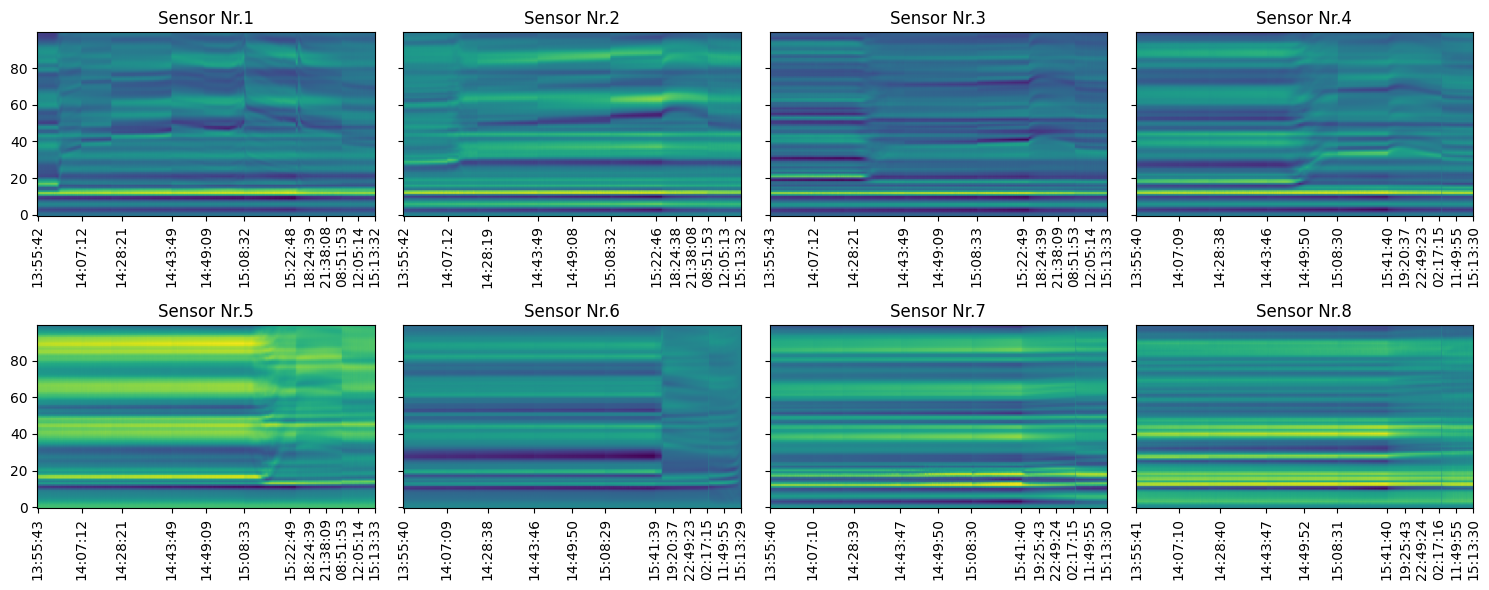

In [4]:
def gen_metrics(arr: np.ndarray, ignore_n: int):
    offset = ignore_n if arr.shape[1] > ignore_n else arr.shape[1]
    sliced = arr[:, offset:] if offset else arr
    p = np.nanmax(np.abs(sliced), axis=1)
    p2p = np.nanmax(sliced, axis=1) - np.nanmin(sliced, axis=1)
    abs_vals = np.abs(sliced)
    abs_vals[np.isnan(abs_vals)] = -np.inf
    peak_pos = np.argmax(abs_vals, axis=1) + offset
    peak_neg = np.argmin(sliced, axis=1) + offset
    return p, p2p, peak_pos, peak_neg, sliced, offset

# Order of sensors
df_sel_1 = df.loc[df["rx"].apply(lambda rx: 3 in rx) & (df["wulpus"] == "E")]
df_sel_2 = df.loc[df["rx"].apply(lambda rx: 1 in rx) & (df["wulpus"] == "E")]
df_sel_3 = df.loc[df["rx"].apply(lambda rx: 7 in rx) & (df["wulpus"] == "E")]
df_sel_4 = df.loc[df["rx"].apply(lambda rx: 3 in rx) & (df["wulpus"] == "D")]
df_sel_5 = df.loc[df["rx"].apply(lambda rx: 5 in rx) & (df["wulpus"] == "E")]
df_sel_6 = df.loc[df["rx"].apply(lambda rx: 1 in rx) & (df["wulpus"] == "D")]
df_sel_7 = df.loc[df["rx"].apply(lambda rx: 5 in rx) & (df["wulpus"] == "D")]
df_sel_8 = df.loc[df["rx"].apply(lambda rx: 7 in rx) & (df["wulpus"] == "D")]
df_sel = [df_sel_1, df_sel_2, df_sel_3, df_sel_4, df_sel_5, df_sel_6, df_sel_7, df_sel_8]
# display(df_sel.head())


data:list[Data] = [] 
for i, dataset in enumerate(df_sel):
    flattened_df, meas_cols = flatten_df_measurements(
        dataset, sample_crop=SAMPLE_CROP)
    data.append(Data(
        flattened_df=flattened_df,
        y=flattened_df[meas_cols].to_numpy(dtype=float),
        x=flattened_df.index,
        raw_df = dataset
    ))


fig, axs = plt.subplots(2, 4, sharey=True, figsize=(15, 6))
for i, sensor in enumerate(data):
    ax = axs[i//4, i%4]
    ax.set_title(f"Sensor Nr.{i+1}")
    im = ax.imshow(sensor["y"].T, aspect='auto', cmap='viridis', origin='lower')
    format_time_xticks(ax, index=sensor["x"], num_ticks=5, rotation=90)

# plt.colorbar(im)
plt.tight_layout()


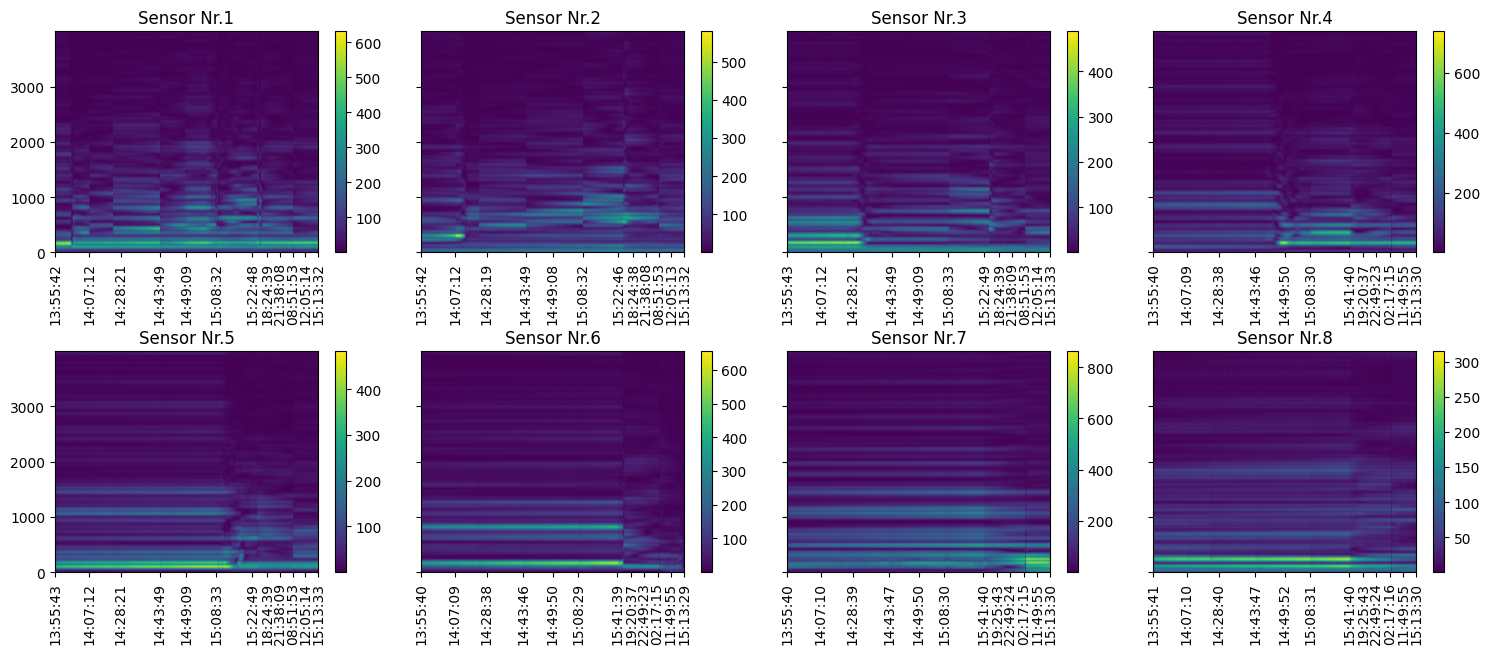

In [5]:
from wulpus.data_processing import MeasurementProcessor

fig, axs = plt.subplots(2, 4, sharey=True, figsize=(15, 6))
plt.tight_layout(h_pad=5.0)
    
for i, sensor in enumerate(data):
    processor = MeasurementProcessor()

    # Process each measurement and collect wavelets
    wavelet_list = []
    for measurement in sensor["raw_df"]["measurement"]:
        res = processor.process_measurement(
            measurement={
                "data": measurement,
                "rx": [0],
                "tx": [0],
                "time": 0,
                "mesh_origin": 0,
            },
            config=config,
        )
        wavelet_list.append(np.asarray(res.wavelet).ravel())

    # Stack into a 2D array. If wavelets have different lengths, pad with NaN.
    max_len = max(len(w) for w in wavelet_list)
    wavelet_values = np.full((len(wavelet_list), max_len), np.nan, dtype=float)
    sensor["wavelet_values"] = wavelet_values
    for j, w in enumerate(wavelet_list):
        wavelet_values[j, : len(w)] = w

    ax = axs[i//4, i%4]
    ax.set_title(f"Sensor Nr.{i+1}")
    im = ax.imshow(wavelet_values.T, aspect='auto', cmap='viridis', origin='lower')
    format_time_xticks(ax, index=sensor["x"], num_ticks=5, rotation=90)
    
    plt.colorbar(im)

# Flowfront detection

In [15]:
ground_truth_us = [
        (1766008620000000, 1766008740000000),
        (1766009160000000, 1766009400000000),
        (1766010420000000, 1766010960000000),
        (1766011500000000, 1766011920000000),
        (1766012760000000, 1766013840000000),
        (0, 0),
        (0, 0),
        (0, 0),
    ]

In [16]:
def print_flowfront(ax: plt.Axes, x_loc: Optional[int], label: Optional[str] = None):
    if x_loc is not None:
        ax.axvline(x_loc, color='red', linestyle='--', linewidth=1, alpha=1)
        if label:
            ax.text(0.5, 0.5, 'matplotlib', horizontalalignment='center',
                    verticalalignment='center', label=label, rotation=90, va='center')


def get_peak_metrics(arr: np.ndarray, ignore_n: Optional[int] = None) -> PeakData:
    sliced = arr[:, ignore_n:]
    p = np.nanmax(np.abs(sliced), axis=1)
    p2p = np.nanmax(sliced, axis=1) - np.nanmin(sliced, axis=1)
    abs_vals = np.abs(sliced)
    abs_vals[np.isnan(abs_vals)] = -np.inf
    peak_position_pos = np.argmax(abs_vals, axis=1) + ignore_n
    peak_position_neg = np.argmin(sliced, axis=1) + ignore_n
    return PeakData(p=p, p2p=p2p, peak_position_pos=peak_position_pos, peak_position_neg=peak_position_neg)


def print_ground_truth(ax: plt.Axes, sensor: Data, sensor_index):
    ground_truth_idx = to_index_range(sensor["x"], ground_truth_us[sensor_index])
    if ground_truth_idx[0] and ground_truth_idx[1]:
        ax.axvspan(ground_truth_idx[0], ground_truth_idx[1],
                   color="green", alpha=0.15, label="Ground truth")

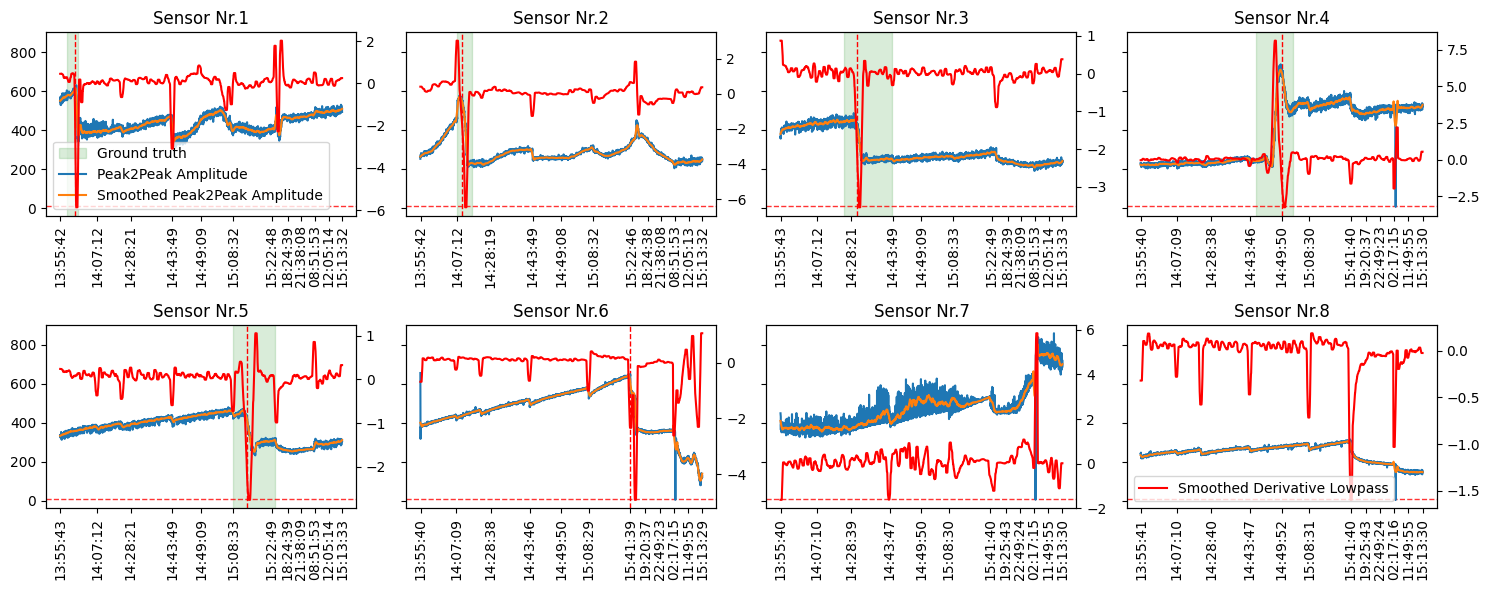

In [17]:
fig, axs = plt.subplots(2, 4, sharey=True, figsize=(15, 6))
plt.tight_layout(h_pad=5.0)
IGNORE_FIRST_N_SAMPLES = 10
for i, sensor in enumerate(data):
    peaks = get_peak_metrics(sensor["wavelet_values"], ignore_n=IGNORE_FIRST_N_SAMPLES)
    sensor["peaks"] = peaks
    smooth_p2p = savgol_filter(peaks['p2p'], 50, 2)

    smooth_deriv = savgol_filter(peaks['p2p'], 50, 2, deriv=1)
    smooth_deriv_lowpass = medfilt(smooth_deriv, kernel_size=29)

    curing_index = np.where(smooth_deriv_lowpass <= -2)[0]
    curing_index = int(curing_index[0]) if curing_index.size else None

    ax = axs[i//4, i % 4]
    ax.set_title(f"Sensor Nr.{i+1}")    
    print_ground_truth(ax, sensor, i)
    print_flowfront(ax, curing_index)
    ax.axhline(IGNORE_FIRST_N_SAMPLES, color='red', linestyle='--', linewidth=1, alpha=0.8)
    ax.plot(peaks['p2p'], label='Peak2Peak Amplitude')
    ax.plot(smooth_p2p, label='Smoothed Peak2Peak Amplitude')
    ax2 = ax.twinx()
    ax2.plot(smooth_deriv_lowpass,
             label='Smoothed Derivative Lowpass', color='red')
    fig.tight_layout()
    format_time_xticks(ax, index=sensor["x"], num_ticks=5, rotation=90)
    if i == 0:
        ax.legend()
    if i == 7:
        ax2.legend()

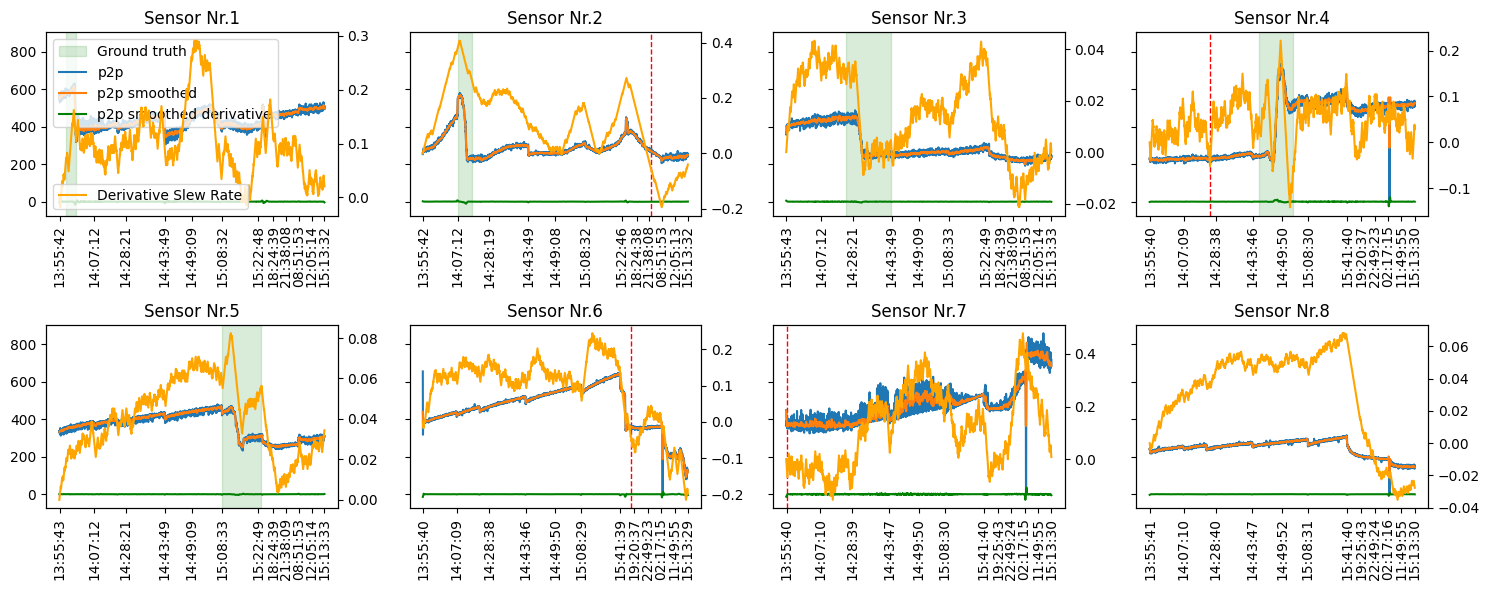

In [18]:
def limit_slew_rate(data: np.ndarray, max_change: float) -> np.ndarray:
    limited_data = np.zeros_like(data)
    limited_data[0] = 0
    for i in range(1, len(data)):
        change = data[i] - limited_data[i - 1]
        limited_change = np.clip(change, -max_change, max_change)
        limited_data[i] = limited_data[i - 1] + limited_change
    return limited_data

fig, axs = plt.subplots(2, 4, sharey=True, figsize=(15, 6))
plt.tight_layout(h_pad=5.0)
for i, sensor in enumerate(data):   
    peaks = get_peak_metrics(sensor["wavelet_values"], ignore_n=10)
    smooth_p2p = savgol_filter(peaks['p2p'], 20, 2)
    smooth_deriv = savgol_filter(peaks['p2p'], 20, 2, deriv=1)
    max_allowed_jump = 0.001 * np.var(smooth_deriv)
    deriv_slew_rate = limit_slew_rate(smooth_deriv, max_allowed_jump)

    curing_index = np.where(deriv_slew_rate <= -0.05)[0]
    curing_index = int(curing_index[0]) if curing_index.size else None

    ax = axs[i//4, i % 4]
    ax.set_title(f"Sensor Nr.{i+1}")
    print_ground_truth(ax, sensor, i)
    print_flowfront(ax, curing_index)
    ax.plot(sensor['peaks']['p2p'], label='p2p')
    ax.plot(smooth_p2p, label='p2p smoothed')
    ax.plot(smooth_deriv, label='p2p smoothed derivative', color='green')
    ax2 = ax.twinx()
    ax2.plot(deriv_slew_rate, label='Derivative Slew Rate', color='orange')
    fig.tight_layout()
    format_time_xticks(ax, index=sensor["x"], num_ticks=5, rotation=90)
    if i == 0:
        ax.legend()
        ax2.legend()

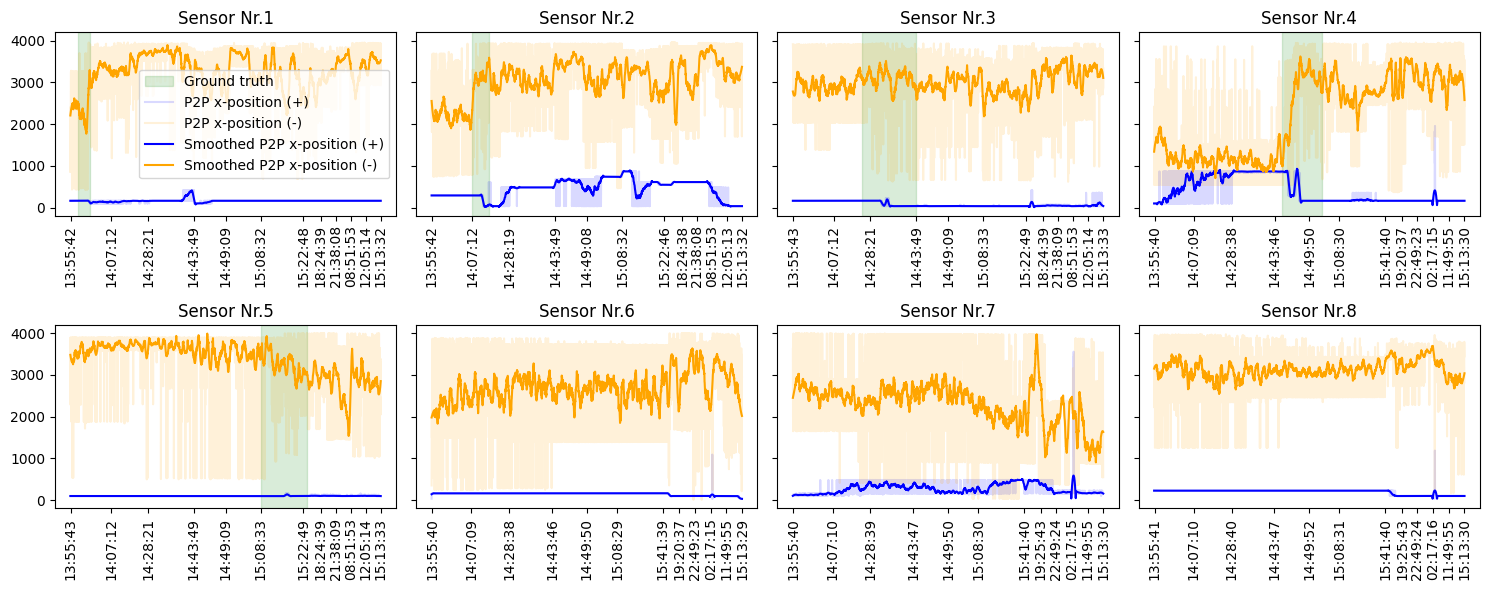

In [19]:
fig, axs = plt.subplots(2, 4, sharey=True, figsize=(15, 6))
plt.tight_layout(h_pad=5.0)
for i, sensor in enumerate(data):
    peak_position_pos = sensor["peaks"]['peak_position_pos']
    peak_position_neg = sensor["peaks"]['peak_position_neg']

   
    ax = axs[i//4, i % 4]
    ax.set_title(f"Sensor Nr.{i+1}") 
    print_ground_truth(ax, sensor, i)
    ax.plot(peak_position_pos, label='P2P x-position (+)', color='blue', alpha=0.15)
    ax.plot(peak_position_neg, label='P2P x-position (-)', color='orange', alpha=0.15)
    ax.plot(savgol_filter(peak_position_pos, 50, 2), color='blue', label='Smoothed P2P x-position (+)')
    ax.plot(savgol_filter(peak_position_neg, 50, 2), color='orange', label='Smoothed P2P x-position (-)')
        

    fig.tight_layout()
    format_time_xticks(ax, index=sensor["x"], num_ticks=5, rotation=90)
    if i == 0:
        ax.legend()

# Speed of Flowfront

In [47]:
dstnc_betw_sens = [0, 5, 5, 2.5, 2.8] # cm
pos_sens = np.cumsum(dstnc_betw_sens)

 
-7.017e-05 x + 0.3534


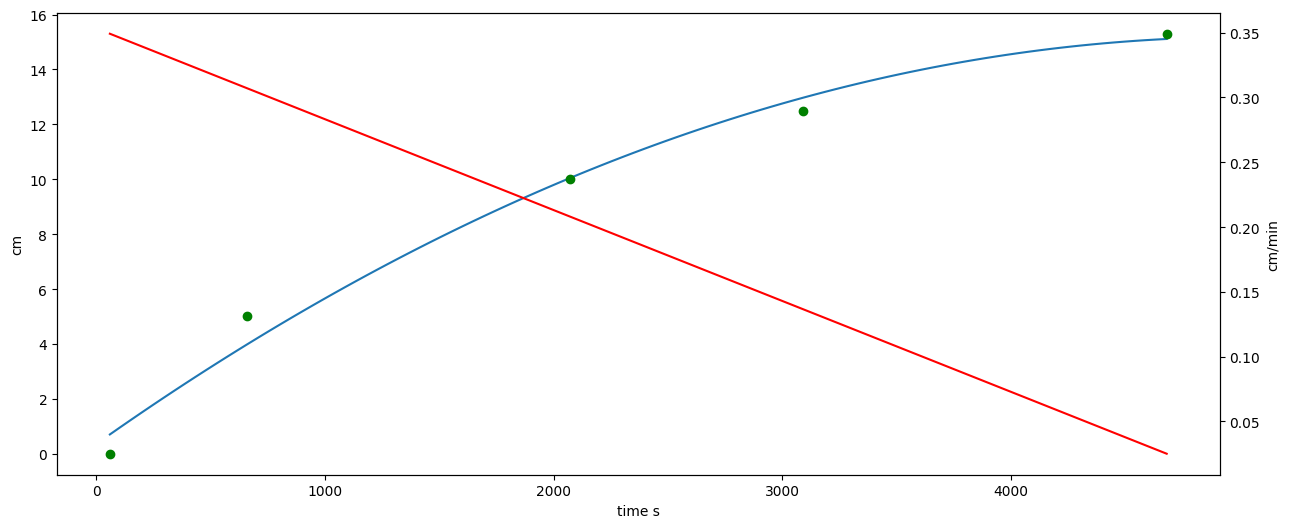

In [81]:
flwfnt_mid_sensor = [(int((((front+end) /2) - ground_truth_us[0][0])/1e6)) for (front, end) in ground_truth_us][:5]
poly_fun = np.poly1d(np.polyfit(flwfnt_mid_sensor, pos_sens, 2))
poly_x = np.linspace(flwfnt_mid_sensor[0], flwfnt_mid_sensor[-1], 100)
poly_y = poly_fun(poly_x)

speed_fun = poly_fun.deriv() * 60
speed_y = speed_fun(poly_x)

fig, ax = plt.subplots(figsize=(15, 6)) 
ax.set_xlabel("time s")
ax.set_ylabel("cm")
ax.plot(poly_x, poly_y)
ax2 = plt.twinx()
ax2.set_ylabel("cm/min")
ax2.plot(poly_x, speed_y, color="red")
for i in range(len(dstnc_betw_sens)):
    ax.plot(flwfnt_mid_sensor[i], pos_sens[i], "o", color="green")

print(speed_fun)

# Curing